In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import folium

In [40]:
df = pd.read_csv("../../Data/idrice.csv")

df.head()

,province,production,productivity,harvest_area,year
0,Aceh,1861567100,5649,329515.78,2018
1,Sumatera Utara,2108284720,5165,408176.45,2018
2,Sumatera Barat,1483076480,4737,313050.82,2018
3,Riau,266375530,3728,71448.08,2018
4,Jambi,383045740,4444,86202.68,2018


In [ ]:
df = df.dropna()
df = df[df['province'] != 'Indonesia']
df.reset_index(drop=True, inplace=True)

In [45]:
coords = {
    "Aceh": (5.55, 95.32),
    "Sumatera Utara": (3.59, 98.67),
    "Sumatera Barat": (-0.95, 100.35),
    "Riau": (0.51, 101.45),
    "Jambi": (-1.59, 103.61),
    "Sumatera Selatan": (-2.99, 104.76),
    "Bengkulu": (-3.80, 102.26),
    "Lampung": (-5.45, 105.26),
    "Kepulauan Bangka Belitung": (-2.13, 106.10),
    "Kepulauan Riau": (0.91, 104.45),
    "DKI Jakarta": (-6.21, 106.85),
    "Jawa Barat": (-6.90, 107.60),
    "Jawa Tengah": (-7.15, 110.14),
    "DI Yogyakarta": (-7.80, 110.36),
    "Jawa Timur": (-7.54, 112.23),
    "Banten": (-6.11, 106.16),
    "Bali": (-8.34, 115.09),
    "Nusa Tenggara Barat": (-8.58, 116.11),
    "Nusa Tenggara Timur": (-10.18, 123.58),
    "Kalimantan Barat": (0.12, 109.34),
    "Kalimantan Tengah": (-1.61, 113.03),
    "Kalimantan Selatan": (-3.32, 114.59),
    "Kalimantan Timur": (0.52, 117.15),
    "Kalimantan Utara": (3.32, 117.58),
    "Sulawesi Utara": (1.49, 124.84),
    "Sulawesi Tengah": (-0.90, 119.85),
    "Sulawesi Selatan": (-5.14, 119.41),
    "Sulawesi Tenggara": (-3.99, 122.52),
    "Gorontalo": (0.69, 122.45),
    "Sulawesi Barat": (-2.68, 118.88),
    "Maluku": (-3.70, 128.17),
    "Maluku Utara": (0.79, 127.38),
    "Papua Barat": (-0.86, 134.06),
    "Papua": (-4.27, 138.96),
}

df["lat"] = df["province"].map(lambda x: coords[x][0])
df["lon"] = df["province"].map(lambda x: coords[x][1])

df.head()

,province,production,productivity,harvest_area,year,lat,lon
0,Aceh,1861567100,5649,329515.78,2018,5.55,95.32
1,Sumatera Utara,2108284720,5165,408176.45,2018,3.59,98.67
2,Sumatera Barat,1483076480,4737,313050.82,2018,-0.95,100.35
3,Riau,266375530,3728,71448.08,2018,0.51,101.45
4,Jambi,383045740,4444,86202.68,2018,-1.59,103.61


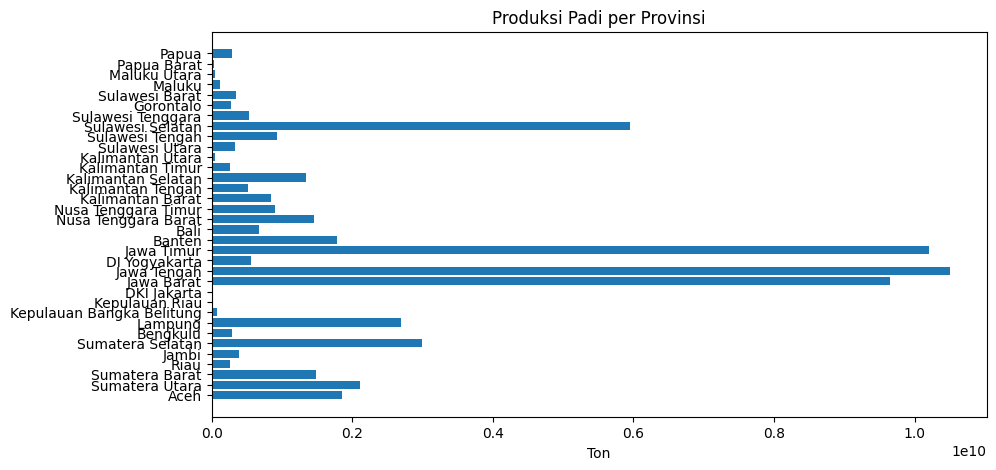

In [46]:
plt.figure(figsize=(10,5))
plt.barh(df['province'], df['production'])
plt.title("Produksi Padi per Provinsi")
plt.xlabel("Ton")
plt.show()

In [47]:
X = df[['production', 'productivity', 'harvest_area']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [48]:
db = DBSCAN(eps=0.8, min_samples=3)
clusters = db.fit_predict(X_scaled)

df['cluster'] = clusters
df.head()

,province,production,productivity,harvest_area,year,lat,lon,cluster
0,Aceh,1861567100,5649,329515.78,2018,5.55,95.32,0
1,Sumatera Utara,2108284720,5165,408176.45,2018,3.59,98.67,0
2,Sumatera Barat,1483076480,4737,313050.82,2018,-0.95,100.35,0
3,Riau,266375530,3728,71448.08,2018,0.51,101.45,0
4,Jambi,383045740,4444,86202.68,2018,-1.59,103.61,0


In [49]:
valid_clusters = df[df['cluster'] != -1]

if len(valid_clusters['cluster'].unique()) > 1:
    score = silhouette_score(
        valid_clusters[['production','productivity','harvest_area']], 
        valid_clusters['cluster']
    )
    print("Silhouette Score:", score)
else:
    print("Silhouette tidak bisa dihitung (cluster hanya 1 atau semua -1).")

Silhouette Score: 0.8088049667027484


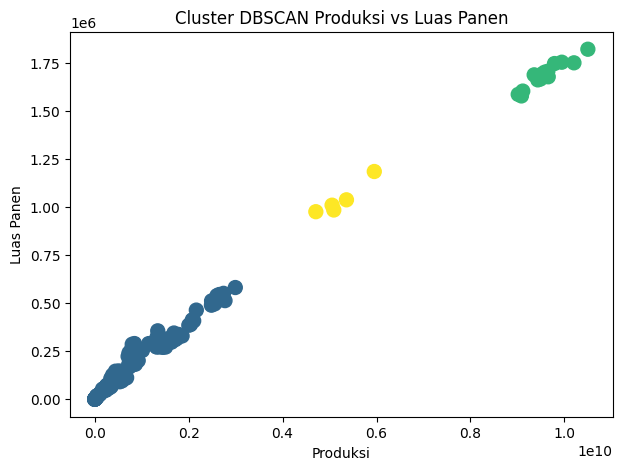

In [51]:
plt.figure(figsize=(7,5))
plt.scatter(df['production'], df['harvest_area'], c=df['cluster'], s=100)
plt.xlabel("Produksi")
plt.ylabel("Luas Panen")
plt.title("Cluster DBSCAN Produksi vs Luas Panen")
plt.show()

In [52]:
m = folium.Map(location=[-2, 117], zoom_start=5)

colors = ['red','blue','green','purple','orange','darkred','cadetblue']

for _, row in df.iterrows():
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=8,
        popup=f"<b>{row['province']}</b><br>Produksi: {row['production']} ton<br>Cluster: {row['cluster']}",
        color=colors[row['cluster'] % len(colors)],
        fill=True,
        fill_color=colors[row['cluster'] % len(colors)]
    ).add_to(m)

# Legend
legend_html = """
<div style="
position: fixed;
bottom: 40px;
left: 40px;
width: 180px;
background: white;
border: 2px solid grey;
z-index:9999;
font-size: 14px;
padding: 10px;
">
<b>Cluster Legend</b><br>
"""

for c in sorted(df['cluster'].unique()):
    legend_html += f"""
    <i style='background:{colors[c % len(colors)]};
              width:10px;height:10px;
              float:left;margin-right:5px;'></i>
    Cluster {c}<br>
    """

legend_html += "</div>"

m.get_root().html.add_child(folium.Element(legend_html))

m
